## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Juan José Mican Rodríguez" # @param {"type":"string"}
carnet = 1000116549 # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Un vivero está analizando el crecimiento de la producción de nuevas plantas a partir de un
proceso de reproducción controlada. Se ha observado que el número de nuevas plantas producidas en el mes n se comportaba con la siguiente estructura o forma, en el mes 0 se produjeron 0 nuevas plantas, y en el mes 1 se produjo una nueva planta. A partir del mes 2, el número de nuevas plantas producidas es igual a la suma de las plantas producidas durante los dos meses anteriores, debido a que las plantas que alcanzan su etapa de reproducción generan nuevos brotes siguiendo este patrón de crecimiento (Relación de recurrencia y casos base):

T(n) = 0 si n = 0

T(n) = 1 si n = 1

T(n) = T(n-1) + T(n-2) si n ≥ 2

Se determinará con memoización (guardar datos ya calculados) cuántas nuevas plantas serán producidas en el mes n.

## 2) Requerimientos **[2 pts]**

Lista requerimientoss

**Funcionales**

FR1: El sistema debe recibir un número entero n ≥ 0 (que sea dígito y no otro tipo de caracter o signo) como entrada.

FR2: El sistema debe retornar T(n), el número de nuevos suscriptores en el mes n.

FR3: El sistema debe manejar los casos base T(0)=0 y T(1)=1 sí o sí.

FR4: El sistema debe calcular T(n) usando la recurrencia T(n)=T(n-1)+T(n-2) para n≥2.

FR5: El sistema debe almacenar (memoizar) los resultados intermedios ya calculados para reutilizarlos y no recalcularlos.

FR6: El sistema rechaza apropiadamente entradas inválidas (n negativo, no entero).

**No funcionales**

NFR1 (rendimiento): El algoritmo debe ejecutarse en tiempo O(n), evitando el crecimiento exponencial de la versión sin memoización.

NFR2 (uso de memoria): El uso de memoria debe ser O(n) como máximo (o O(1) si se usa la versión iterativa).

NFR3 (escalabilidad): El sistema debe soportar valores de n suficientemente grandes sin fallar por límite de recursión.

NFR4 (mantenibilidad): El código debe estar documentado y modularizado.

NFR5 (confiabilidad): El sistema debe producir resultados consistentes y verificables.

NFR6 (usabilidad): La salida debe presentarse en un formato claro y legible para el usuario.



## 3) Historias de usuario **[2 pts]**

**HU1** Como analista de la plataforma, quiero calcular el número de nuevas plantas en un mes n para proyectar el crecimiento futuro de un campo en una zona de cultivos.

Criterios de aceptación:

Dado n=0, el sistema retorna 0.

Dado n=1, el sistema retorna 1.

Dado n=6, el sistema retorna 8.

**HU2** Como desarrollador del sistema, quiero que los cálculos usen memoización para evitar recomputar los mismos valores y mejorar el rendimiento.

Criterios de aceptación:

Dado n=30, el algoritmo se ejecuta en menos de 1 segundo.

El número de llamadas recursivas efectivas es O(n), no exponencial.

**HU3** Como usuario del reporte de crecimiento, quiero ingresar cualquier mes n válido para obtener la proyección sin errores.

Criterios de aceptación:

Dado n negativo, el sistema muestra un mensaje de error en vez de fallar.

**HU4** Como gerente de producto, quiero ver cómo crece el número de plantas mes a mes para tomar decisiones de infraestructura o cultivos con anticipación.

Criterios de aceptación:

Dado un rango de meses [0, n], el sistema puede listar T(0), T(1), ..., T(n) en orden.

## 4) Diagramas de flujo **[5 pts]**

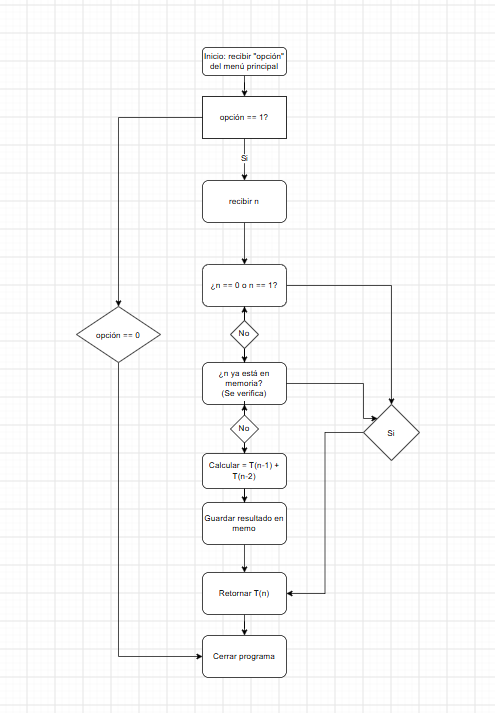

### 5) Análisis de complejidad **[15 pts]**

Función T(n): para el algoritmo con memoización, cada valor de n de 0 hasta n se calcula una sola vez, la primera vez que se necesita se computa y se guarda, las siguientes veces se lee directo del diccionario en O(1). Por eso:

Número de subproblemas distintos: n+1 (de 0 a n)

Trabajo por subproblema: O(1)

T(n) = O(n), tanto en tiempo como en espacio (por el diccionario memo y la pila de recursión)

Justificación: No es exponencial ya que sin memoización, fib(n) llama a fib(n-1) y fib(n-2), y cada una de esas vuelve a llamar a sus propias sub-llamadas, recalculando el mismo valor cientos de veces o sea, superposición de subproblemas. Con memo, cada subproblema se resuelve una vez y se reutiliza, por eso pasa a O(n).

Mejor y peor caso: aquí no varían según el "orden de los datos", sino solo según n, así que mejor y peor caso son iguales: O(n).

F(n) = 1 ----> Mejor caso

F(n) = n ----> Peor caso (con memoización)

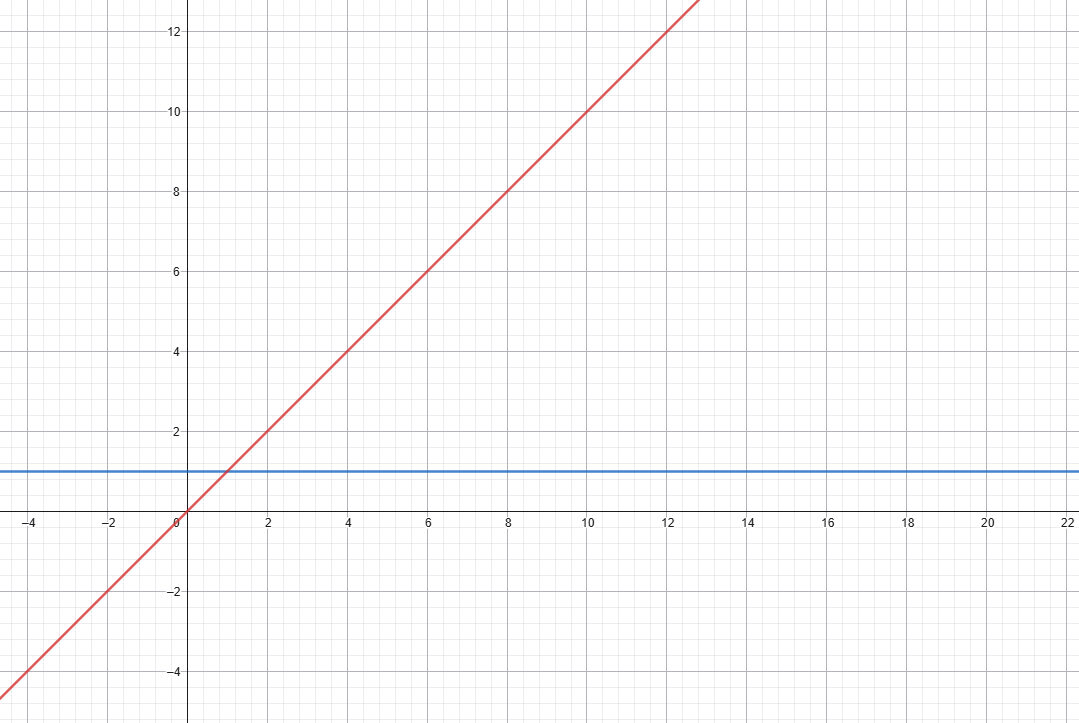

## 6) Código funcional **[15 pts]**


In [ ]:
def plantas(n, memoria=None):
    if n < 0:
        raise ValueError("El número de mes (n) no puede ser negativo.")
    if memoria is None:
        memoria = {}
    if n == 0:
        return 0
    if n == 1:
        return 1
    if n in memoria:
        return memoria[n]
    memoria[n] = plantas(n - 1, memoria) + plantas(n - 2, memoria)
    return memoria[n]

def caracter_valido(msj="\t(n): "):
    while True:
        mes = input(msj)
        if not mes.isdigit():
            print("\t\n\tValor inválido, por favor ingrese solo dígitos numéricos (ni signos, ni comas, ni letras).")
            continue
        try:
            numero = int(mes)
            if numero >= 0:
                return numero
            else:
                print("\t\n\tValor inválido, por favor ingrese un número entero positivo.")
        except ValueError:
            print("\t\n\tValor inválido, por favor ingrese un número entero positivo.")

def main():
  while True:
    print("\t\t\tCÁLCULO DE PLANTAS EN CIERTO MES")
    print("\t\t\n1. Calcular plantas")
    print("\t\t\n0. Salir del programa")
    opcion = caracter_valido("\n\tIngrese una opción:")

    if opcion == 1:
      while True:
        n = caracter_valido("\n\tIngrese el número de mes para calcular la cantidad de plantas: ")
        try:
            calculo = plantas(n)
            print(f"\t\n\tEn el mes {n} existen {calculo} plantas.")
        except ValueError as e:
            print(f"\t\n\tError: {e}")
        print("\n\tVolviendo al menú principal...")
        break

    elif opcion == 0:
      print("\t\n\tCerrando programa...")
      break

    else:
      print("\t\n\tOpción inválida. Por favor, ingrese 1 o 0.")

main()

			CÁLCULO DE PLANTAS EN CIERTO MES
		
1. Calcular plantas
		
0. Salir del programa

	Ingrese una opción:p
	
	Valor inválido, por favor ingrese solo dígitos numéricos (ni signos, ni comas, ni letras).

	Ingrese una opción:1

	Ingrese el número de mes para calcular la cantidad de plantas: 8
	
	En el mes 8 existen 21 plantas.

		Calcular otro mes (y/n):y

	Ingrese el número de mes para calcular la cantidad de plantas: 6
	
	En el mes 6 existen 8 plantas.

		Calcular otro mes (y/n):n
			CÁLCULO DE PLANTAS EN CIERTO MES
		
1. Calcular plantas
		
0. Salir del programa

	Ingrese una opción:0
	
	Cerrando programa...


## 7) Tests aplicados **[15 pts]**

In [ ]:
import time

assert plantas(0) == 0
assert plantas(1) == 1
assert plantas(2) == 1
assert plantas(3) == 2
assert plantas(5) == 5
assert plantas(6) == 8
assert plantas(15) == 610


inicio = time.time()
plantas(500)
assert time.time() - inicio < 1, "El cálculo para n=500 debería ser rápido (menos de 1 segundo)"

try:
    plantas(-1)
    assert False, "Debería haber lanzado un ValueError para n negativo"
except ValueError:
    pass
